This assignment analyzes system login data from an organization to identify patterns and detect suspicious activities.

The dataset contains:
- timestamp: login time
- user_id: user identifier
- ip_address: login IP
- country: login location
- success: login status (True/False)
- os: operating system used

The goal is to:
- Explore login behavior
- Identify failed login attempts
- Detect suspicious patterns

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("system_logins.csv")
df.head()

,timestamp,user_id,ip_address,country,success,os
0,2026-04-20 08:15:23,user_1,192.168.1.10,USA,True,Windows
1,2026-04-20 08:17:45,user_2,192.168.1.11,UK,False,Linux
2,2026-04-20 08:20:10,user_3,192.168.1.12,Germany,True,MacOS
3,2026-04-20 09:05:33,user_1,192.168.1.13,USA,False,Windows
4,2026-04-20 09:10:12,user_2,192.168.1.14,India,False,Linux


In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   timestamp   29 non-null     str  
 1   user_id     29 non-null     str  
 2   ip_address  29 non-null     str  
 3   country     29 non-null     str  
 4   success     29 non-null     bool 
 5   os          29 non-null     str  
dtypes: bool(1), str(5)
memory usage: 1.3 KB


,timestamp,user_id,ip_address,country,success,os
count,29,29,29,29,29,29
unique,29,10,29,5,2,3
top,2026-04-20 08:15:23,user_4,192.168.1.10,USA,False,MacOS
freq,1,11,1,16,19,15


The dataset contains 30 entries with no missing values.
Most columns are categorical except 'success' which is boolean.

In [ ]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Check duplicates
df.duplicated().sum()

np.int64(0)

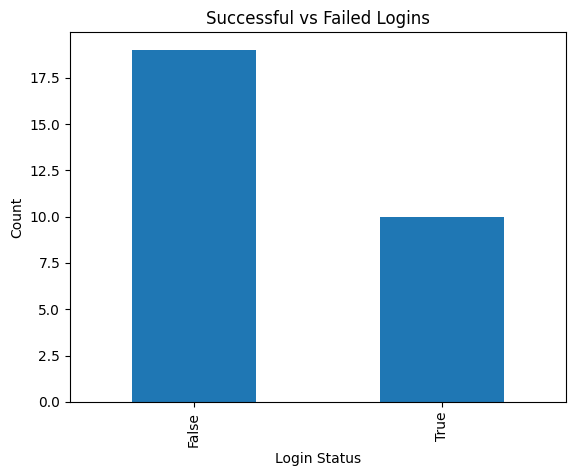

In [ ]:
df['success'].value_counts()
df['success'].value_counts().plot(kind='bar')
plt.title("Successful vs Failed Logins")
plt.xlabel("Login Status")
plt.ylabel("Count")
plt.show()

There are more successful logins than failed ones, but failed attempts still exist and may indicate security threats.

In [ ]:
failed_logins = df[df['success'] == False]
failed_logins['user_id'].value_counts()

user_id
user_4    10
user_2     2
user_6     2
user_7     2
user_9     2
user_1     1
Name: count, dtype: int64

Some users have multiple failed attempts, which may indicate brute-force attacks or unauthorized access attempts.

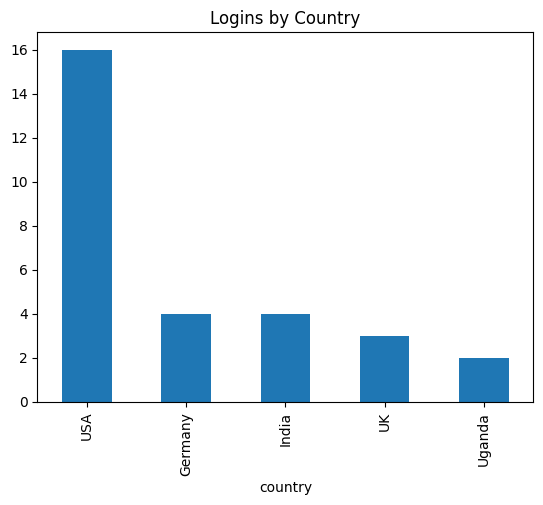

In [ ]:
df['country'].value_counts()
df['country'].value_counts().plot(kind='bar')
plt.title("Logins by Country")
plt.show()

Most logins come from a few countries. Logins from unusual locations could be suspicious.

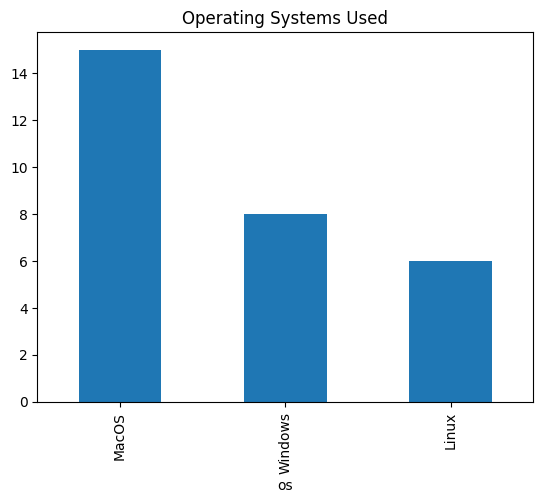

user_id
user_4     11
user_6      3
user_7      3
user_9      3
user_1      2
user_2      2
user_3      2
user_5      1
user_8      1
user_10     1
Name: count, dtype: int64

In [ ]:
df['os'].value_counts()
df['os'].value_counts().plot(kind='bar')
plt.title("Operating Systems Used")
plt.show()
df['user_id'].value_counts()

Users with high login frequency should be monitored, especially if combined with failed attempts.

In [ ]:
# Users with failed logins
suspicious_users = df[df['success'] == False]['user_id'].value_counts()

# Users logging from multiple countries
multi_country_users = df.groupby('user_id')['country'].nunique()
multi_country_users[multi_country_users > 1]

user_id
user_2    2
user_3    2
Name: country, dtype: int64

In [ ]:
# Users with failed logins
suspicious_users = df[df['success'] == False]['user_id'].value_counts()

# Users logging from multiple countries
multi_country_users = df.groupby('user_id')['country'].nunique()
multi_country_users[multi_country_users > 1]

user_id
user_2    2
user_3    2
Name: country, dtype: int64

Users logging in from multiple countries may indicate compromised accounts.
Repeated failed logins suggest possible brute-force attacks.

The analysis revealed:
- A number of failed login attempts indicating potential security risks
- Certain users with repeated failed logins
- Login activity from multiple countries, which may suggest account compromise

Recommendations:
- Implement account lockout after multiple failed attempts
- Monitor unusual geographic login patterns
- Strengthen authentication mechanisms